# Hiring Pipeline Optimization — Interactive Exploration

Run each cell top to bottom. By the end you'll see:
- Historical data overview: hire rate, outcome distribution, stage funnel
- How precision, recall, and cost evolve as the algorithm learns
- How each stage's threshold converges over time
- What difference `cost_weight` makes

In [1]:
# Colab setup — clones the repo if it doesn't exist locally
import os
if not os.path.isdir('src') and not os.path.isdir('../src'):
    os.system('git clone https://github.com/fatisati/hiring-bandit.git')
    os.chdir('hiring-bandit')

In [2]:
import sys
import os

# works from repo root (Colab) or notebooks/ subfolder (local)
src_dir = 'src' if os.path.isdir('src') else os.path.join('..', 'src')
sys.path.insert(0, src_dir)

import matplotlib.pyplot as plt
import pandas as pd

from generate_data import generate_dataset
from bandit import HiringPipeline
from evaluate import Evaluator

STAGE_COSTS = {'s0': 1, 's1': 3, 's2': 8, 's3': 15}

## 1. Generate Data

500 candidates. First 50 are historical (warm start). Remaining 450 are online.

In [3]:
data      = generate_dataset(n=500, seed=42)
historical = [c for c in data if c['phase'] == 'historical']
online     = [c for c in data if c['phase'] == 'online']

df_hist = pd.DataFrame(historical)

hired      = df_hist['hired'].sum()
not_hired  = len(df_hist) - hired
truly_good = df_hist['ground_truth_hire'].sum()

print(f"Historical candidates : {len(df_hist)}")
print(f"Truly good (top N)    : {truly_good} ({100*truly_good//len(df_hist)}%)")
print(f"Hired                 : {hired} ({100*hired//len(df_hist)}%)")

df_hist[['candidate_id', 'true_quality', 's0_score', 's1_score', 's2_score', 's3_score',
         'ground_truth_hire', 'hired', 'outcome']].head(8)

Historical candidates : 50
Truly good (top N)    : 11 (22%)
Hired                 : 9 (18%)


,candidate_id,true_quality,s0_score,s1_score,s2_score,s3_score,ground_truth_hire,hired,outcome
0,C001,62.8,59.4,NaN,NaN,NaN,0,0,0.0
1,C002,63.3,77.4,61.8,NaN,NaN,0,0,0.0
2,C003,42.5,49.2,NaN,NaN,NaN,0,0,0.0
3,C004,61.0,56.7,NaN,NaN,NaN,0,0,0.0
4,C005,66.7,71.4,80.7,70.7,67.1,0,0,0.0
5,C006,53.9,33.6,NaN,NaN,NaN,0,0,0.0
6,C007,68.7,94.9,69.2,68.1,NaN,0,0,0.0
7,C008,73.0,43.9,NaN,NaN,NaN,0,0,0.0


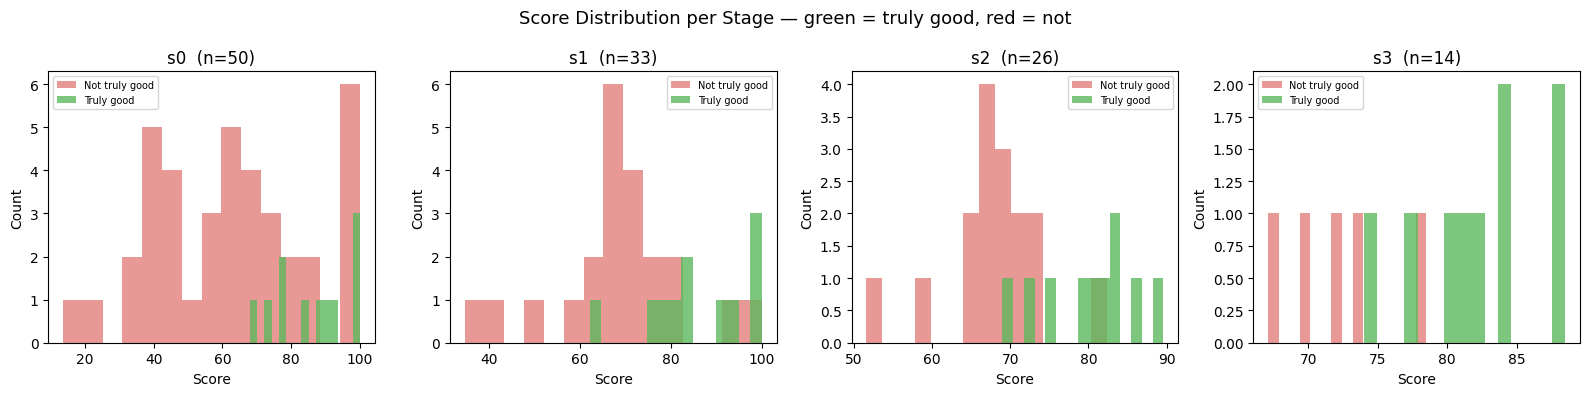

In [4]:
stages = ['s0', 's1', 's2', 's3']
fig, axes = plt.subplots(1, len(stages), figsize=(16, 4))
fig.suptitle('Score Distribution per Stage — green = truly good, red = not', fontsize=13)

for ax, stage in zip(axes, stages):
    scores = df_hist[[f'{stage}_score', 'ground_truth_hire']].dropna()
    good = scores[scores['ground_truth_hire'] == 1][f'{stage}_score']
    bad  = scores[scores['ground_truth_hire'] == 0][f'{stage}_score']
    ax.hist(bad,  bins=15, color='#d9534f', alpha=0.6, label='Not truly good')
    ax.hist(good, bins=15, color='#5cb85c', alpha=0.8, label='Truly good')
    ax.set_title(f'{stage}  (n={len(scores)})')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Naive Policy Baseline

Before the algorithm learns anything, we can measure how well the **fixed thresholds** (the company's old policy) performed on historical data. This is the baseline the online algorithm should improve upon.

In [5]:
h_hired      = df_hist['hired'].sum()
h_truly_good = df_hist['ground_truth_hire'].sum()
h_correct    = ((df_hist['hired'] == 1) & (df_hist['ground_truth_hire'] == 1)).sum()
h_cost       = df_hist['total_cost'].sum()

h_precision    = h_correct / h_hired      if h_hired      else 0
h_recall       = h_correct / h_truly_good if h_truly_good else 0
h_cost_per_hire = h_cost   / h_hired      if h_hired      else 0

print("Naive policy (fixed thresholds) on historical data")
print("---------------------------------------------------")
print(f"Truly good candidates : {h_truly_good} / {len(df_hist)}")
print(f"Hired                 : {h_hired}")
print(f"Correct hires (TP)    : {h_correct}")
print(f"Precision             : {h_precision:.2f}")
print(f"Recall                : {h_recall:.2f}")
print(f"Total cost            : {h_cost} hrs")
print(f"Cost per hire         : {h_cost_per_hire:.1f} hrs")

Naive policy (fixed thresholds) on historical data
---------------------------------------------------
Truly good candidates : 11 / 50
Hired                 : 9
Correct hires (TP)    : 8
Precision             : 0.89
Recall                : 0.73
Total cost            : 567 hrs
Cost per hire         : 63.0 hrs


## 2. Run the Pipeline

Warm starts on historical data, then processes online candidates one by one.
Thresholds are recorded after every candidate so we can plot convergence.

In [6]:
def run_pipeline(historical, online, exploration=0.1, cost_weight=0.01, batch_size=10):
    pipeline  = HiringPipeline(stage_costs=STAGE_COSTS, exploration=exploration, cost_weight=cost_weight)
    evaluator = Evaluator(batch_size=batch_size)

    pipeline.warm_start(historical)

    threshold_history = {s: [] for s in pipeline.stages}

    for candidate in online:
        result  = pipeline.process(candidate)
        reward  = pipeline.compute_reward(result, candidate['outcome'])
        pipeline.update(result['thresholds'], result['visited_stages'], reward)
        evaluator.record(candidate, result)

        for stage in pipeline.stages:
            threshold_history[stage].append(pipeline.bandits[stage].select_threshold())

    return evaluator, threshold_history


evaluator, threshold_history = run_pipeline(historical, online)
evaluator.print_report()


 batch |  seen |  precision |  recall |  total cost |  cost/hire
------------------------------------------------------------------
     0 |    10 |       1.00 |    0.33 |        45.0 |       45.0
     1 |    10 |       1.00 |    0.50 |        98.0 |       49.0
     2 |    10 |       0.50 |    0.33 |        87.0 |       43.5
     3 |    10 |       0.50 |    1.00 |        90.0 |       45.0
     4 |    10 |       1.00 |    1.00 |       103.0 |       34.3
     5 |    10 |       1.00 |    0.75 |       120.0 |       40.0
     6 |    10 |       1.00 |    1.00 |        71.0 |       35.5
     7 |    10 |       0.00 |    0.00 |        56.0 |        N/A
     8 |    10 |       1.00 |    0.40 |        68.0 |       34.0
     9 |    10 |       1.00 |    0.67 |        74.0 |       37.0
    10 |    10 |       1.00 |    0.60 |       111.0 |       37.0
    11 |    10 |       1.00 |    0.80 |       117.0 |       29.2
    12 |    10 |       1.00 |    1.00 |        90.0 |       45.0
    13 |    10 |      

## 3. Metrics Over Time

Metrics are **cumulative** — each point reflects all candidates seen so far, not just the current batch.
This smooths out the noise from small batches and shows the actual learning trend.

Dashed lines show the naive baseline (fixed thresholds on historical data).
If the algorithm is working, precision and recall should rise above the baseline and cost per hire should fall below it.

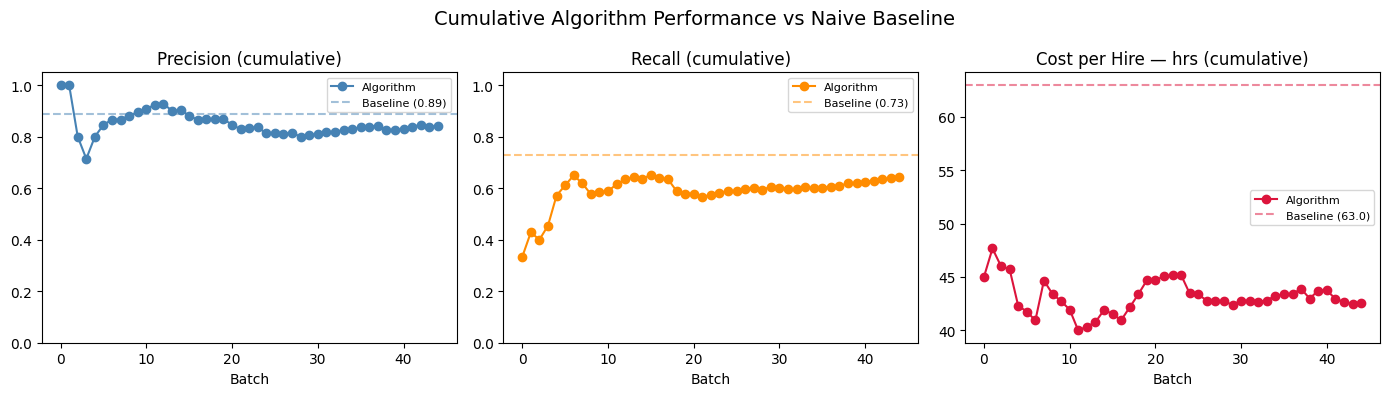

In [7]:
cum = evaluator.cumulative()

# filter out None entries (batches with no hires yet)
p_pts   = [(r['batch'], r['precision'])     for r in cum if r['precision']     is not None]
r_pts   = [(r['batch'], r['recall'])        for r in cum if r['recall']        is not None]
cph_pts = [(r['batch'], r['cost_per_hire']) for r in cum if r['cost_per_hire'] is not None]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Cumulative Algorithm Performance vs Naive Baseline', fontsize=14)

# Precision
if p_pts:
    bx, by = zip(*p_pts)
    axes[0].plot(bx, by, marker='o', color='steelblue', label='Algorithm')
axes[0].axhline(h_precision, color='steelblue', linestyle='--', alpha=0.5, label=f'Baseline ({h_precision:.2f})')
axes[0].set_title('Precision (cumulative)')
axes[0].set_xlabel('Batch')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

# Recall
if r_pts:
    bx, by = zip(*r_pts)
    axes[1].plot(bx, by, marker='o', color='darkorange', label='Algorithm')
axes[1].axhline(h_recall, color='darkorange', linestyle='--', alpha=0.5, label=f'Baseline ({h_recall:.2f})')
axes[1].set_title('Recall (cumulative)')
axes[1].set_xlabel('Batch')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

# Cost per hire
if cph_pts:
    bx, by = zip(*cph_pts)
    axes[2].plot(bx, by, marker='o', color='crimson', label='Algorithm')
axes[2].axhline(h_cost_per_hire, color='crimson', linestyle='--', alpha=0.5, label=f'Baseline ({h_cost_per_hire:.1f})')
axes[2].set_title('Cost per Hire — hrs (cumulative)')
axes[2].set_xlabel('Batch')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# Verdict: use final cumulative values (reflect all online candidates seen)
cum = evaluator.cumulative()
final = cum[-1] if cum else {}

final_precision     = final.get('precision')     or 0
final_recall        = final.get('recall')        or 0
final_cost_per_hire = final.get('cost_per_hire') or 0

def verdict(algo, base, higher_is_better=True):
    diff = algo - base
    pct  = abs(diff) / base * 100 if base else 0
    improved = diff > 0 if higher_is_better else diff < 0
    symbol = '\u2713' if improved else '\u2717'
    direction = '+' if diff > 0 else ''
    return f"{symbol}  {algo:.2f}  (baseline {base:.2f}, {direction}{diff:.2f}, {pct:.0f}% {'better' if improved else 'worse'})"

print("Algorithm vs Naive Baseline  (cumulative — all online candidates)")
print("=" * 60)
print(f"Precision     : {verdict(final_precision,     h_precision,    higher_is_better=True)}")
print(f"Recall        : {verdict(final_recall,        h_recall,       higher_is_better=True)}")
print(f"Cost per hire : {verdict(final_cost_per_hire, h_cost_per_hire, higher_is_better=False)}")
print()

n_improved = sum([
    final_precision     > h_precision,
    final_recall        > h_recall,
    final_cost_per_hire < h_cost_per_hire,
])
print(f"Overall: {n_improved}/3 metrics improved over baseline.")

Algorithm vs Naive Baseline  (cumulative — all online candidates)
Precision     : ✗  0.84  (baseline 0.89, -0.05, 5% worse)
Recall        : ✗  0.64  (baseline 0.73, -0.08, 12% worse)
Cost per hire : ✓  42.53  (baseline 63.00, -20.47, 32% better)

Overall: 1/3 metrics improved over baseline.


## 4. Threshold Convergence

Each line shows the threshold the algorithm is currently using for that stage.
You should see it stabilise after enough candidates.

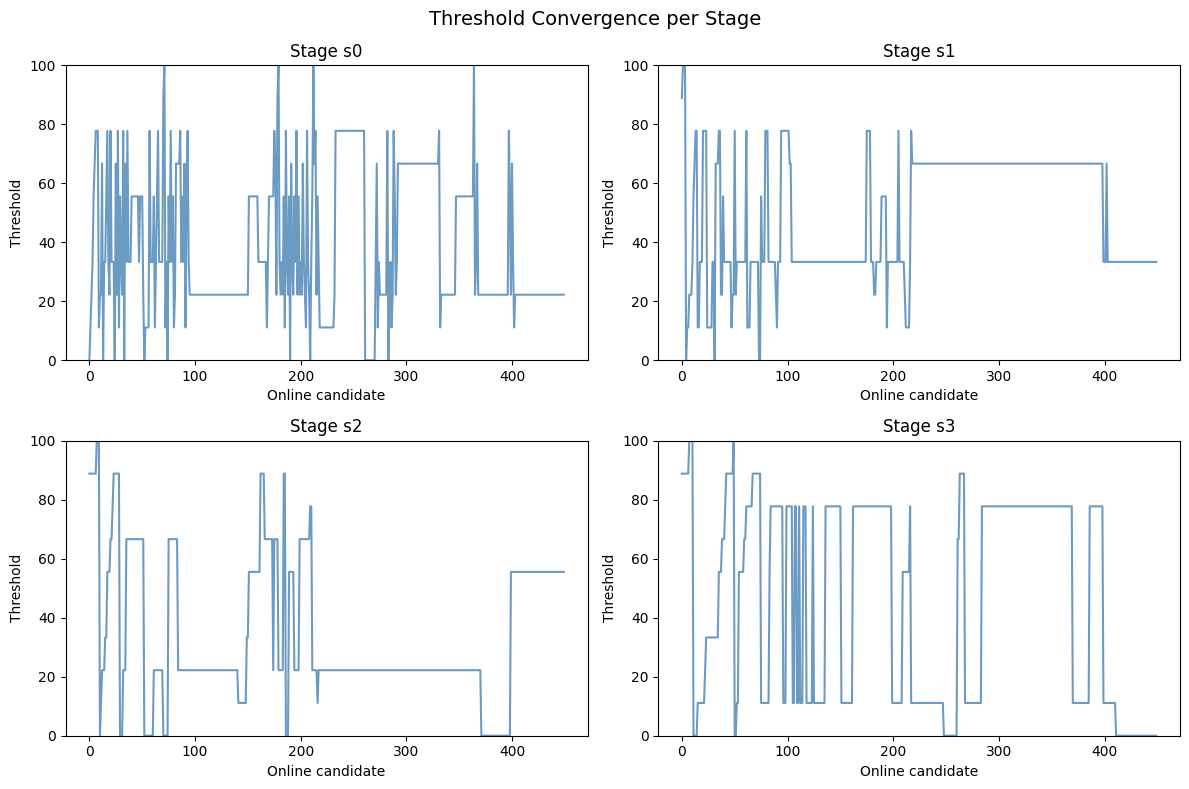

In [9]:
stages = list(STAGE_COSTS.keys())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Threshold Convergence per Stage', fontsize=14)

for i, stage in enumerate(stages):
    ax = axes[i // 2, i % 2]
    ax.plot(threshold_history[stage], color='steelblue', alpha=0.8)
    ax.set_title(f'Stage {stage}')
    ax.set_xlabel('Online candidate')
    ax.set_ylabel('Threshold')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 5. Cost Weight Comparison

`cost_weight=0` — cost blind, only cares about hire quality  
`cost_weight=0.01` (default) — penalises total hours spent (hired + rejected)

**Note:** `cost_weight` optimises **total cost**, not cost per hire. A higher cost_weight makes the algorithm reject candidates earlier, spending fewer hours overall — but cost per hire may not improve (or can even rise) because the candidates that do get hired still go through all stages. The plot below shows total cost, which is what the reward directly targets.

In [ ]:
ev_no_cost, _ = run_pipeline(historical, online, cost_weight=0.0)
ev_cost, _    = run_pipeline(historical, online, cost_weight=0.01)

cum_no_cost = ev_no_cost.cumulative()
cum_cost    = ev_cost.cumulative()

b = [r['batch'] for r in cum_no_cost]

# running total cost per batch
def running_total_cost(ev):
    total = 0
    result = []
    for m in ev.batches:
        total += m.total_cost
        result.append(total)
    return result

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('cost_weight=0.0 vs cost_weight=0.01', fontsize=13)

# Precision
for key, ax, label, color_pair in zip(
    ['precision', 'recall'],
    axes[:2],
    ['Precision', 'Recall'],
    [('steelblue', 'navy'), ('darkorange', 'saddlebrown')]
):
    vals_0  = [r[key] for r in cum_no_cost]
    vals_01 = [r[key] for r in cum_cost]
    x0  = [b_ for b_, v in zip(b, vals_0)  if v is not None]
    y0  = [v  for v in vals_0  if v is not None]
    x01 = [b_ for b_, v in zip(b, vals_01) if v is not None]
    y01 = [v  for v in vals_01 if v is not None]
    ax.plot(x0,  y0,  marker='o', label='cost_weight=0.0',  color=color_pair[0])
    ax.plot(x01, y01, marker='s', label='cost_weight=0.01', color=color_pair[1], linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('Batch')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

# Total cost (cumulative) — what cost_weight actually penalises
tc_0  = running_total_cost(ev_no_cost)
tc_01 = running_total_cost(ev_cost)
axes[2].plot(b, tc_0,  marker='o', label='cost_weight=0.0',  color='crimson')
axes[2].plot(b, tc_01, marker='s', label='cost_weight=0.01', color='darkred', linestyle='--')
axes[2].set_title('Total Cost (hrs) — what cost_weight penalises')
axes[2].set_xlabel('Batch')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

def _cum_final(ev, key):
    vals = [r[key] for r in ev.cumulative() if r[key] is not None]
    return vals[-1] if vals else 0

summary = pd.DataFrame({
    'metric': ['precision', 'recall', 'cost/hire', 'total cost'],
    'cost_weight=0.0': [
        f"{_cum_final(ev_no_cost, 'precision'):.2f}",
        f"{_cum_final(ev_no_cost, 'recall'):.2f}",
        f"{_cum_final(ev_no_cost, 'cost_per_hire'):.1f} hrs",
        f"{sum(m.total_cost for m in ev_no_cost.batches):.0f} hrs",
    ],
    'cost_weight=0.01': [
        f"{_cum_final(ev_cost, 'precision'):.2f}",
        f"{_cum_final(ev_cost, 'recall'):.2f}",
        f"{_cum_final(ev_cost, 'cost_per_hire'):.1f} hrs",
        f"{sum(m.total_cost for m in ev_cost.batches):.0f} hrs",
    ],
})
summary